In [1]:
import os
import tarfile
import urllib

In [2]:
DownloadRoot=  "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HousingPath = os.path.join("datasets","housing")             #This uses os.path.join to create a directory,Does it create a folder? No. It is simply saving the "address" into a variable for later use
HousingURL = DownloadRoot + "datasets/housing/housing.tgz"   #This builds the full web address where the compressed data file lives.

In [3]:
def fetch_housing_price(housing_path=HousingPath,housing_url=HousingURL):
    os.makedirs(housing_path, exist_ok=True)                 # This creates the directory datasets/housing on your hard drive.
    tgz_path=os.path.join(housing_path,"housing.tgz")        # stitches the folder name and the file name together e.g datasets\housing\housing.tgz
    urllib.request.urlretrieve(housing_url,tgz_path)       #This is the "downloader,saves the file to tgz_path
    housing_tgz=tarfile.open(tgz_path)                       #opens the compressed "package."
    housing_tgz.extractall(housing_path)                     #"unpacks" the contents (usually a housing.csv file) into your folder.
    housing_tgz.close()                                      #closes the file stream to save memory.




In [4]:
import pandas as pd
def load_housing_data(housing_path=HousingPath):
    csv_path=os.path.join(housing_path,"housing.csv")
    return pd.read_csv(csv_path)


In [5]:
fetch_housing_price()

In [6]:
housing=load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [8]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [9]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


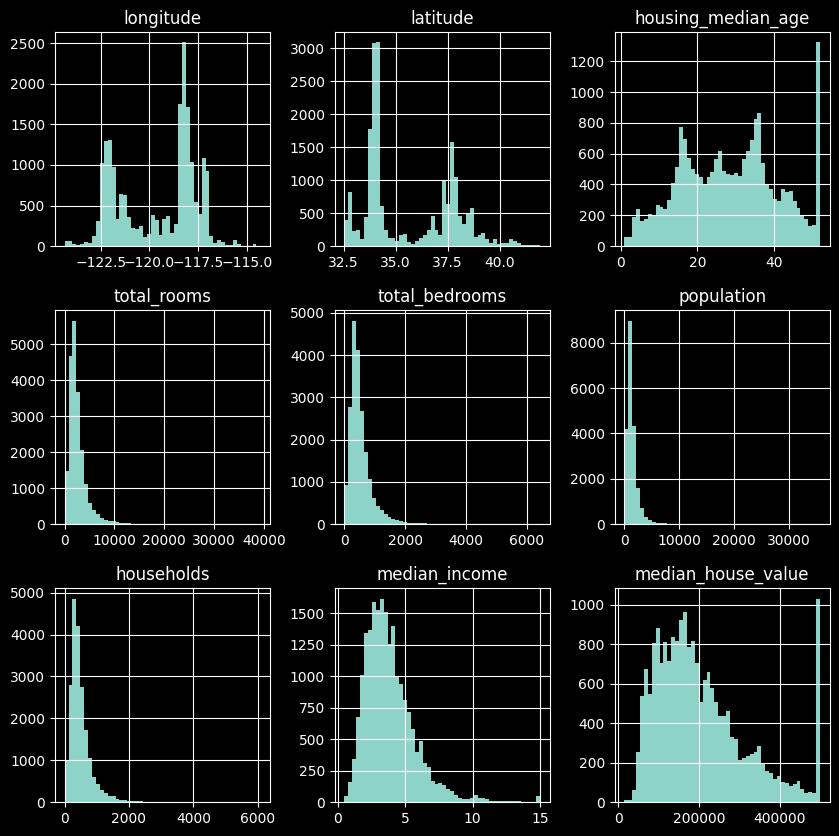

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50,figsize=(10,10))
plt.show()

### Creating a Test And a Training set

In [11]:
import numpy as np
def split_train_test(data,test_ratio):
    np.random.seed(42)                                       # to generate a similar set always
    shuffled_indicies = np.random.permutation(len(data))     # gives you back a list of those numbers in a completely random order.
    test_set_size= int(len(data)*test_ratio)
    test_indicies=shuffled_indicies[:test_set_size]
    train_indicies=shuffled_indicies[test_set_size:]
    return data.iloc[train_indicies],data.iloc[test_indicies]
#train_set,test_set=split_train_test(housing,0.2)
#len(test_set)


In [12]:
#split can be done using sciket learn easily
from sklearn.model_selection import train_test_split

In [13]:
train_set,test_set=train_test_split(housing,test_size=0.2, random_state=42)

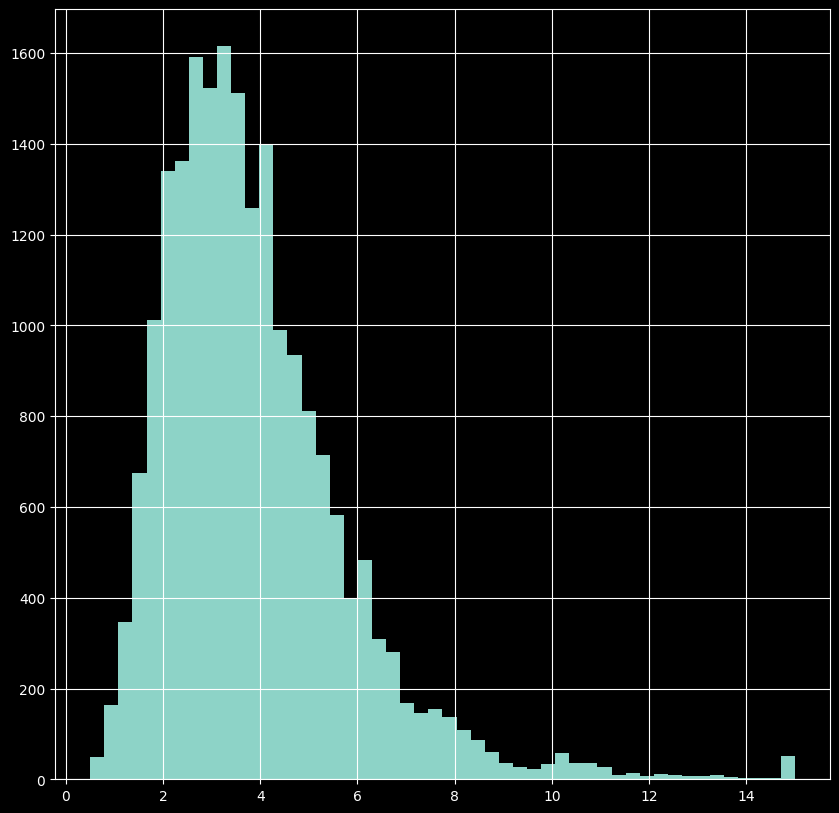

In [14]:
#visualizing median income
housing.median_income.hist(bins=50,figsize=(10,10))
plt.show()

**Median Income Analysis:**

* Most median income values are clustered around $1.5$ to $6$ (i.e., $\$15,000$–$\$60,000$).
* However, some median incomes go far beyond $6$.
* *Critical Rule for Stratification:* You should not have too many strata, and each stratum should be large enough to ensure the data is statistically representative.

$$\text{Stratum Size} \propto \frac{\text{Total Population}}{\text{Number of Strata}}$$

In [15]:
housing["income_cate"] = pd.cut(housing["median_income"],bins=[0.,1.5,3.,4.5,6.,np.inf],labels=[1,2,3,4,5])

<Axes: >

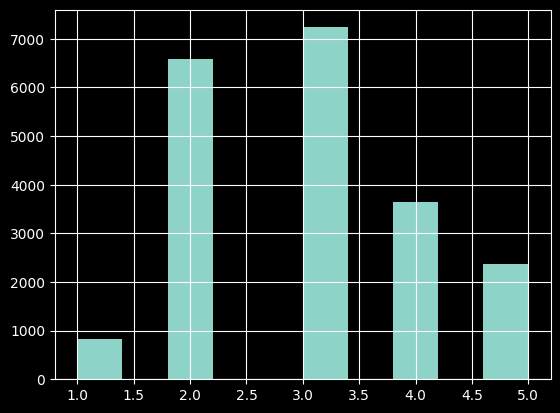

In [16]:
housing["income_cate"].hist()

**Stratified Sampling** to ensure our test set isn't biased.

the population is divided into homogeneous subgroups called strata, and the right
number of instances are sampled from each stratum to guarantee that the test set is
representative of the overall population

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index,test_index in split.split(housing,housing["income_cate"]):
    strat_train_set=housing.loc[train_index]
    strat_test_set=housing.loc[test_index]

In [18]:
strat_train_set["income_cate"].value_counts()/len(strat_train_set)

income_cate
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [19]:
strat_test_set["income_cate"].value_counts()/len(strat_test_set)

income_cate
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [20]:
for set_ in (strat_train_set,strat_test_set):
    set_.drop("income_cate",axis=1,inplace=True)

### Plotting Data For Insights

In [21]:
housing=strat_train_set.copy()

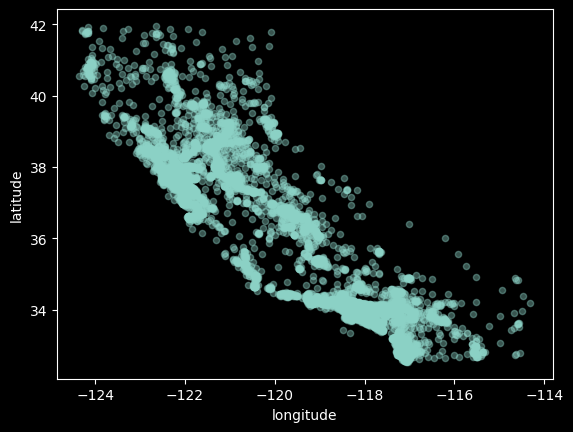

In [22]:
housing.plot(kind="scatter",x="longitude",y="latitude",alpha=0.4)
#plt.scatter(x=housing["longitude"],y=housing["latitude"])
#plt.scatter(data=housing,x="longitude",y="latitude")
plt.show()

$$\text{Position} = (f(\text{longitude}), f(\text{latitude}))$$$$\text{Circle Radius} \propto \sqrt{\text{Population}}$$$$\text{Pixel Color} = \text{Colormap}(\text{Median House Value})$$

<Axes: xlabel='longitude', ylabel='latitude'>

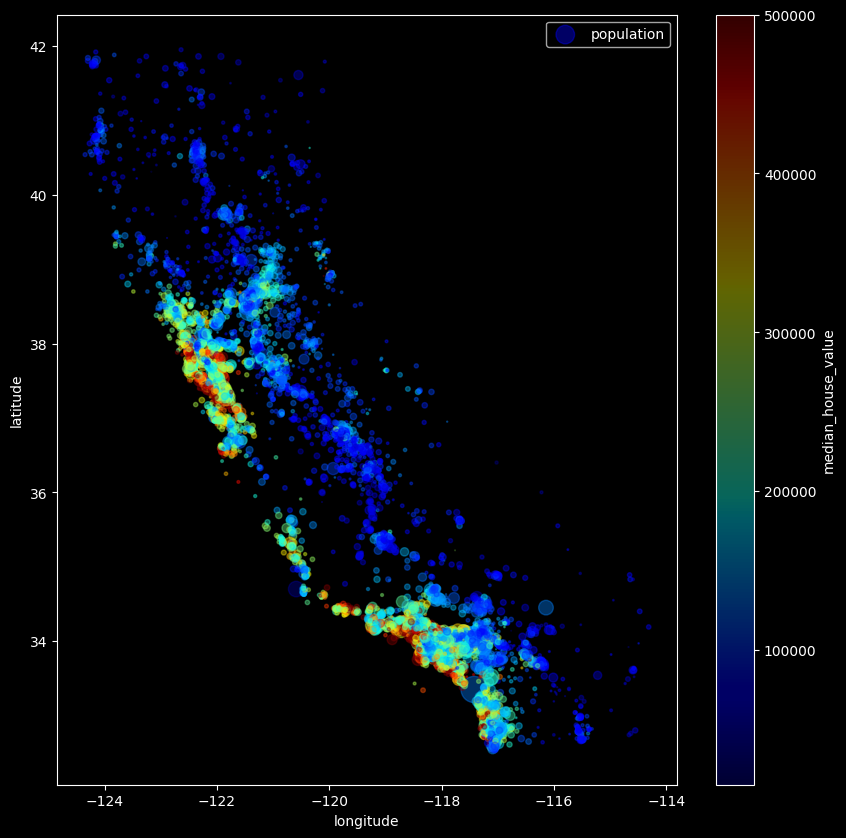

In [23]:
housing.plot(kind="scatter", x="longitude",y="latitude",alpha=0.4,
             s=housing["population"]/100, label="population",
             c="median_house_value",cmap=plt.get_cmap("jet"),figsize=(10,10))

the most expensive areas (red) are also the most populated areas (large circles) and are located near the ocean. This confirms that "proximity to the ocean" and "population density" are likely your strongest features for predicting price!

<Axes: xlabel='median_income', ylabel='median_house_value'>

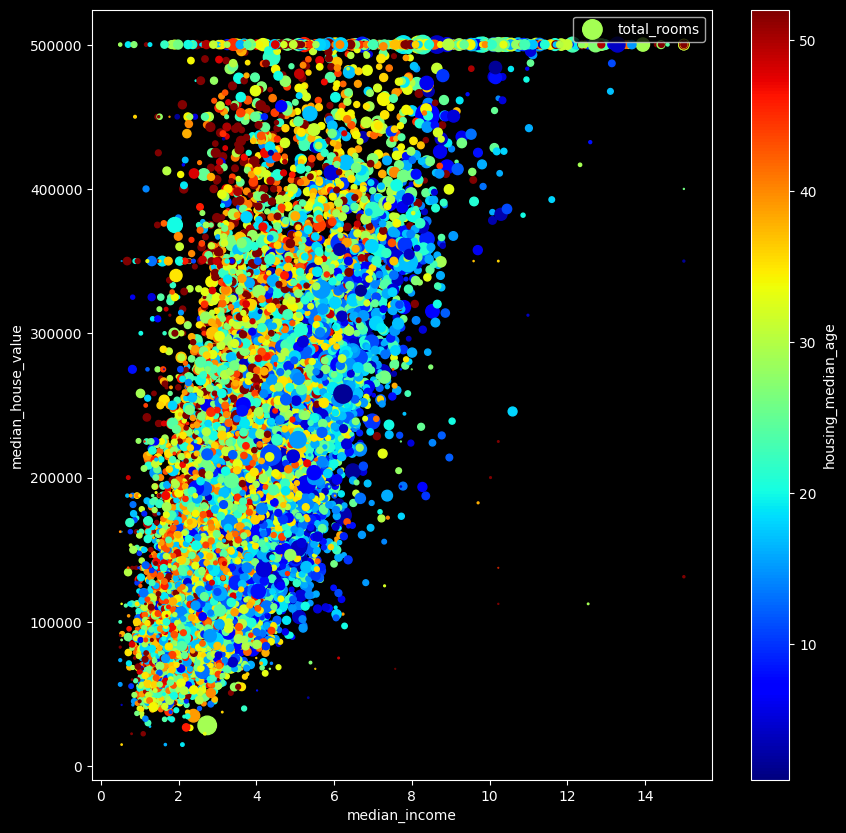

In [24]:
housing.plot(kind="scatter",x="median_income",y="median_house_value",
             figsize=(10,10),
             s=housing["total_rooms"]/100,label="total_rooms",
             c="housing_median_age",cmap=plt.get_cmap("jet")
             )

### Looking for Correlations
compute the standard correlation coefficient: that measures the strength and direction of a linear relationship between two variables.
The correlation coefficient ranges from –1 to 1

In [25]:
corr_matrix = housing.corr(numeric_only=True)

In [26]:
corr_matrix["median_house_value"].sort_values()

latitude             -0.142673
longitude            -0.047466
population           -0.026882
total_bedrooms        0.047781
households            0.064590
housing_median_age    0.114146
total_rooms           0.135140
median_income         0.687151
median_house_value    1.000000
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

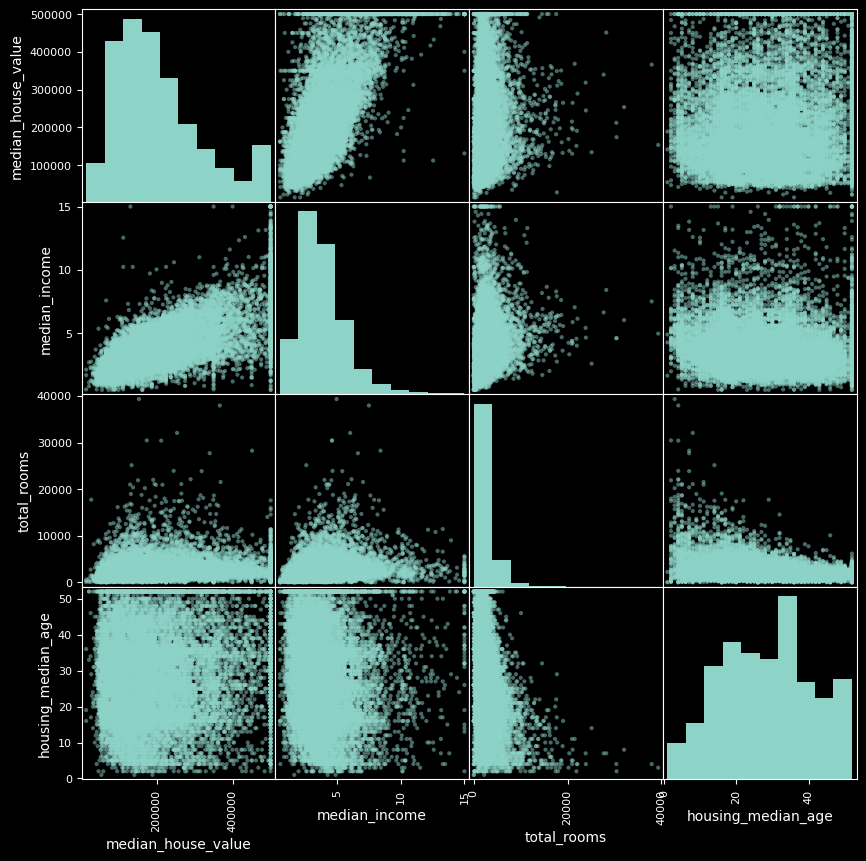

In [27]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value","median_income","total_rooms","housing_median_age"]
scatter_matrix(housing[attributes],figsize=(10,10))

<Axes: xlabel='median_income', ylabel='median_house_value'>

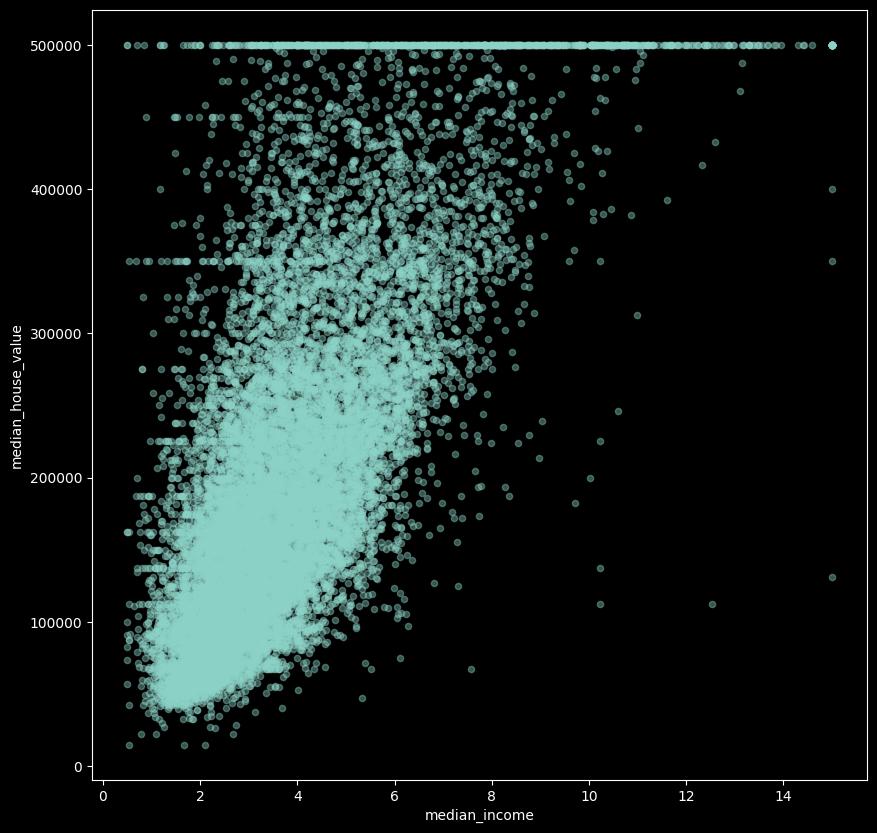

In [28]:
housing.plot(kind="scatter",x="median_income",y="median_house_value",
             figsize=(10,10),alpha=0.4)

### Attribute Combinations

In [29]:
housing["rooms_per_household"]=housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"]=housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

In [30]:
from pandas.plotting import scatter_matrix
corr_matrix=housing.corr(numeric_only=True)

In [31]:
corr_matrix["median_house_value"].sort_values()

bedrooms_per_room          -0.259952
latitude                   -0.142673
longitude                  -0.047466
population                 -0.026882
population_per_household   -0.021991
total_bedrooms              0.047781
households                  0.064590
housing_median_age          0.114146
total_rooms                 0.135140
rooms_per_household         0.146255
median_income               0.687151
median_house_value          1.000000
Name: median_house_value, dtype: float64

In [32]:
housing= strat_train_set.drop(["median_house_value"],axis=1)        #creates a copy of your data without the specified column "median_house_value"
housing_label=strat_train_set["median_house_value"].copy()           #Series containing only the prices/answer key for checking performance

### Data Cleaning

In [33]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
housing_num=housing.drop("ocean_proximity",axis=1)        # median  can be calculated for numeric attributes only


In [34]:
imputer.fit(housing_num)          #calculating median for each attribute we can use fit_transf`rom simultanously as well

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [35]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [36]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [37]:
X= imputer.transform(housing_num)

In [38]:
housing_tr= pd.DataFrame(X,columns=housing_num.columns,index=housing_num.index)

In [39]:
housing_tr.info()   # the null values have been replaced by median

<class 'pandas.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


In [40]:
housing.ocean_proximity.head(10)


12655        INLAND
15502    NEAR OCEAN
2908         INLAND
14053    NEAR OCEAN
20496     <1H OCEAN
1481       NEAR BAY
18125     <1H OCEAN
5830      <1H OCEAN
17989     <1H OCEAN
4861      <1H OCEAN
Name: ocean_proximity, dtype: str

In [41]:
housing.ocean_proximity.unique()

<StringArray>
['INLAND', 'NEAR OCEAN', '<1H OCEAN', 'NEAR BAY', 'ISLAND']
Length: 5, dtype: str

In [42]:

from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder= OrdinalEncoder()
housing_cat=housing[["ocean_proximity"]]
housing_cat_encoded=ordinal_encoder.fit_transform(housing_cat)
print(housing_cat_encoded[:10])

[[1.]
 [4.]
 [1.]
 [4.]
 [0.]
 [3.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [43]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

### One Hot Encoding

In [44]:
from sklearn.preprocessing import OneHotEncoder
oneHotEncoder= OneHotEncoder()
housing_cat_1hot=oneHotEncoder.fit_transform(housing_cat)
print(housing_cat_1hot[:10])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10 stored elements and shape (10, 5)>
  Coords	Values
  (0, 1)	1.0
  (1, 4)	1.0
  (2, 1)	1.0
  (3, 4)	1.0
  (4, 0)	1.0
  (5, 3)	1.0
  (6, 0)	1.0
  (7, 0)	1.0
  (8, 0)	1.0
  (9, 0)	1.0


 a sparse matrix only stores the location of the nonzero
elements. You can use it mostly like a normal 2D array

In [45]:
oneHotEncoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

### Custom Transformer

In [46]:
from sklearn.base import BaseEstimator,TransformerMixin
rooms_ix,bedrooms_ix,population_ix,household_ix=3,4,5,6
class CombinedAttributesAdder(BaseEstimator,TransformerMixin):
    def __init__(self,add_bedrooms_per_room=True):
        self.add_bedrooms_per_room=add_bedrooms_per_room
    def fit(self,X,y=None):
        return self
    def transform(self,X):
        rooms_per_household=X[:,rooms_ix]/X[:,household_ix]
        population_per_household=X[:,population_ix]/X[:,household_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_rooms=X[:,bedrooms_ix]/X[:,rooms_ix]
            return np.c_[X,rooms_per_household,population_per_household,bedrooms_per_rooms]
        else:
            return np.c_[X,rooms_per_household,population_per_household]


In [47]:
attr_adder= CombinedAttributesAdder(add_bedrooms_per_room = False)
housing_extra_attr= attr_adder.fit_transform(housing.values)


### PIPELINES

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
num_pipeline=Pipeline([
    ('inputer',SimpleImputer(strategy="median")),
    ('atribute_adder',CombinedAttributesAdder()),
    ('std_scaler',StandardScaler()),
])
housing_num_train= num_pipeline.fit_transform(housing_num)

### ColumnTransformer

In [49]:
from sklearn.compose import ColumnTransformer

num_attributes=list(housing_num)
cat_attributes=["ocean_proximity"]

full_pipeline=ColumnTransformer([
    ("num",num_pipeline,num_attributes),
    ("cat",OneHotEncoder(),cat_attributes),
])

housing_prepared=full_pipeline.fit_transform(housing)

# Training and Selecting a Model

In [50]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(housing_prepared,housing_label)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
some_data= housing.iloc[:5]
some_label= housing_label[:5]
some_data_prepared = full_pipeline.transform(some_data);
print("predictions : ",lin_reg.predict(some_data_prepared))

predictions :  [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]


In [52]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_label)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
print("labels:",list(some_label))

labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


###  mean_squared_error()

In [54]:
from sklearn.metrics import mean_squared_error
housing_predictions= lin_reg.predict(housing_prepared)
lin_mse=mean_squared_error(housing_label,housing_predictions)
lin_rmse=np.sqrt(lin_mse)
lin_rmse

68627.87390018745

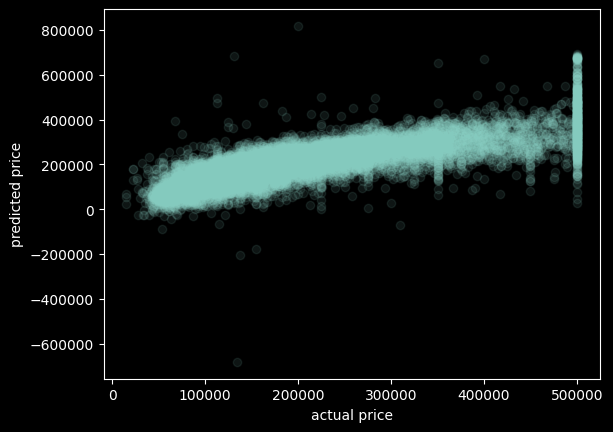

In [55]:
import matplotlib.pyplot as plt
plt.scatter(housing_label,housing_predictions,alpha=0.1)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.show()

### DecisionTreeRegressor

In [56]:
from sklearn.tree import DecisionTreeRegressor
tree_reg=DecisionTreeRegressor()
tree_reg.fit(housing_prepared,housing_label)
housing_predictions=tree_reg.predict(housing_prepared)
tree_mse= mean_squared_error(housing_label,housing_predictions)
tree_rmse= np.sqrt(tree_mse)
tree_rmse

0.0

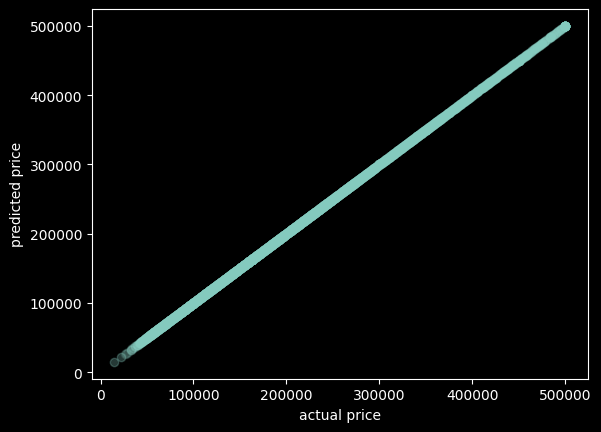

In [57]:
import matplotlib.pyplot as plt
plt.scatter(housing_label,housing_predictions,alpha=0.1)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.show()

### K-fold cross-validation feature.

In [58]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(tree_reg,housing_prepared,housing_label,scoring="neg_mean_squared_error",cv=10)
tree_rmse_scores=np.sqrt(-scores)

In [59]:
def display_scores(scores):
    print("Scores: ",scores)
    print("Mean : ",scores.mean())
    print("Standard Deviation : ", scores.std())

In [60]:
display_scores(tree_rmse_scores)

Scores:  [71968.63528602 70010.84456321 69042.26862043 71648.88476701
 70408.32603006 77835.28389696 72477.2014609  72743.77115073
 69433.32431142 70826.98914479]
Mean :  71639.5529231516
Standard Deviation :  2384.504528531522


In [61]:
lin_scores=cross_val_score(lin_reg,housing_prepared,housing_label,scoring="neg_mean_squared_error",cv=10)
lin_rmse_scores=np.sqrt(-lin_scores)

In [62]:
display_scores(lin_rmse_scores)

Scores:  [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean :  69104.07998247063
Standard Deviation :  2880.328209818065


Because 69,052 < 71,407, the Linear Regression model is actually closer to the real house prices when dealing with the real world. Even though it's simpler its predictions are more accurate on average.

In [63]:
from sklearn.ensemble import RandomForestRegressor
forest_reg=RandomForestRegressor()
forest_reg.fit(housing_prepared,housing_label)
housing_predictions=forest_reg.predict(housing_prepared)
forest_mse=mean_squared_error(housing_label,housing_predictions)
fores_rmse=np.sqrt(housing_predictions)


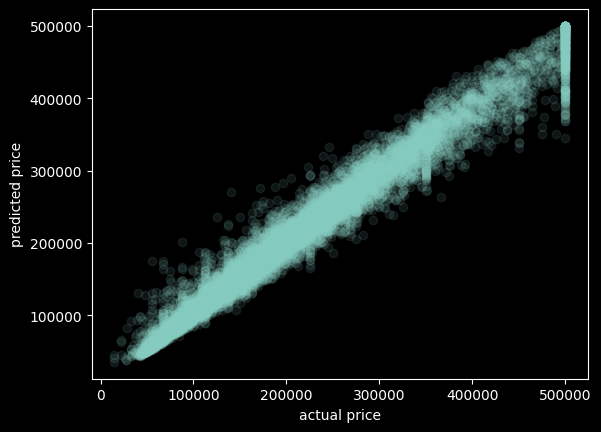

In [64]:
plt.scatter(housing_label,housing_predictions,alpha=0.1)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.show()

In [65]:
forest_scores=cross_val_score(forest_reg,housing_prepared,housing_label,scoring="neg_mean_squared_error",cv=10)
forest_rmse_scores=np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores:  [51448.32893972 48851.34557892 46902.889119   52155.71037907
 47401.53789246 52203.59390663 52506.55228796 49768.35640196
 48811.56635791 54053.59388318]
Mean :  50410.34747468073
Standard Deviation :  2275.097551632334


 Random Forests look very promising. However, note that
the score on the training set is still much lower than on the validation sets, meaning
that the model is still overfitting the training set

In [66]:
import joblib
joblib.dump(forest_reg,"my_forest_model1.pkl")


['my_forest_model1.pkl']

Saving a model



In [67]:

##This restores the model exactly as it was after training
#forest_reg_loaded = joblib.load("my_forest_model.pkl")

## Now you can use it immediately for predictions
#new_predictions = forest_reg_loaded.predict(housing_prepared)


In [68]:
final_model=forest_reg

X_test=strat_test_set.drop("median_house_value",axis=1)
y_test=strat_test_set["median_house_value"].copy()

X_test_prepared=full_pipeline.transform(X_test)


In [70]:
final_predictions=final_model.predict(X_test_prepared)
final_mse=mean_squared_error(y_test,final_predictions)
final_rmse=np.sqrt(final_mse)

In [71]:
final_rmse

48168.483522419636

### Tesing on new data

In [72]:
new_house_data = pd.DataFrame([{
    "longitude": -122.23,
    "latitude": 37.88,
    "housing_median_age": 41.0,
    "total_rooms": 880.0,
    "total_bedrooms": 129.0,
    "population": 322.0,
    "households": 126.0,
    "median_income": 8.3252,
    "ocean_proximity": "NEAR BAY"
}])

In [74]:
# .transform() to prepare this single row
new_house_prepared = full_pipeline.transform(new_house_data)

In [77]:
# Predict the price
prediction = final_model.predict(new_house_prepared)

print(f"The predicted price for this house is: ${prediction[0]}")

The predicted price for this house is: $431432.02
